In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("/content/students.csv")
#print first 5 rows.
print("\nFirst 5 rows:\n")
print(df.head())

#shape and data types.
print("\nShape:", df.shape)
print("\nData types:\n", df.dtypes)

#summary statistics
print("\nSummary:\n")
print(df.describe())

print("\nPass/Fail count:\n")
print(df["passed"].value_counts())

subjects=['math','science','english','history','pe']
print("\nAverage (Pass):\n")
print(df[df["passed"]==1][subjects].mean())

print("\nAverage (Fail):\n")
print(df[df["passed"]==0][subjects].mean())

df["avg"]=df[subjects].mean(axis=1)

top_student=df.loc[df["avg"].idxmax()]
print("\nTop student:\n")
print(top_student["name"],"-",top_student["avg"])





First 5 rows:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary:

            math    science    english    history

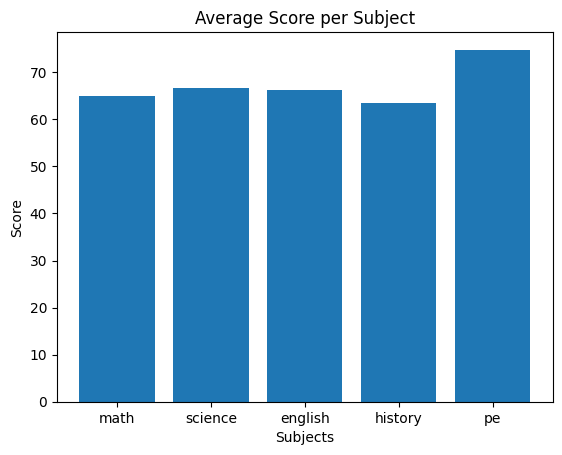

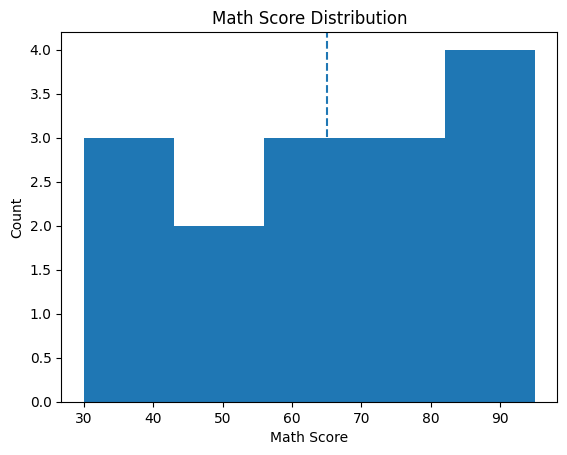

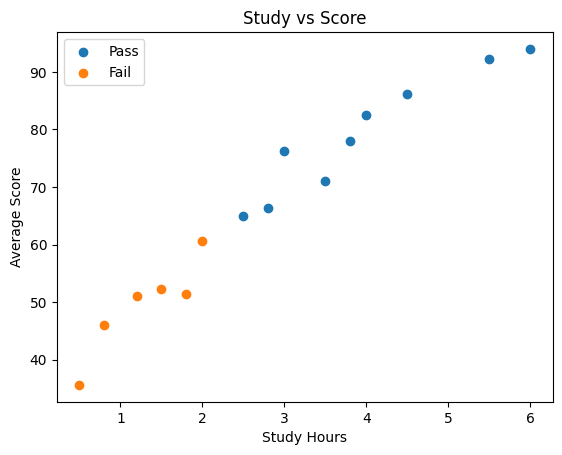

/tmp/ipykernel_1627/1001772517.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att,fail_att],labels=["Pass","Fail"])


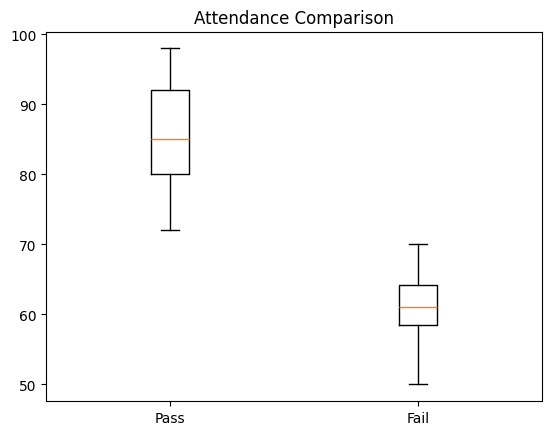

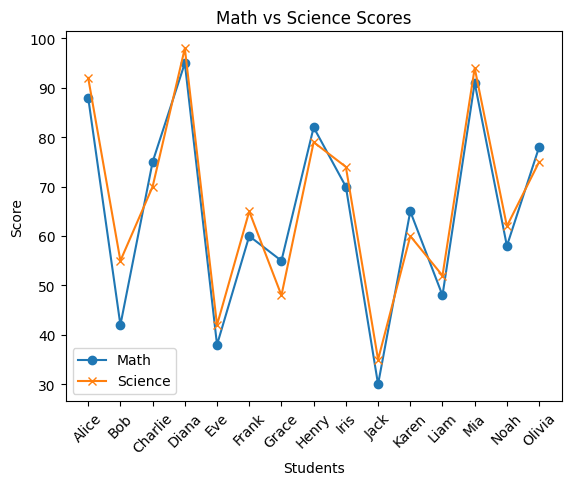

In [11]:
#Task 2
df["avg_score"]=df[subjects].mean(axis=1)

#Bar chart
avg_scores=df[subjects].mean()
plt.bar(subjects,avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.savefig("plot1_bar.png")
plt.show()

#Histogram
plt.hist(df["math"],bins=5)
plt.axvline(df["math"].mean(), linestyle="dashed")
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.savefig("plot2_hist.png")
plt.show()

#Scatter plot
pass_data=df[df["passed"]==1]
fail_data=df[df["passed"]==0]
plt.scatter(pass_data["study_hours_per_day"],pass_data["avg_score"],label="Pass")
plt.scatter(fail_data["study_hours_per_day"],fail_data["avg_score"],label="Fail")
plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Study vs Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

#Box plot
pass_att=df[df["passed"]==1]["attendance_pct"]
fail_att=df[df["passed"]==0]["attendance_pct"]
plt.boxplot([pass_att,fail_att],labels=["Pass","Fail"])
plt.title("Attendance Comparison")
plt.savefig("plot4_box.png")
plt.show()

#Line plot
plt.plot(df["name"],df["math"],marker='o',label="Math")
plt.plot(df["name"],df["science"],marker='x',label="Science")
plt.xticks(rotation=45)
plt.xlabel("Students")
plt.ylabel("Score")
plt.title("Math vs Science Scores")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

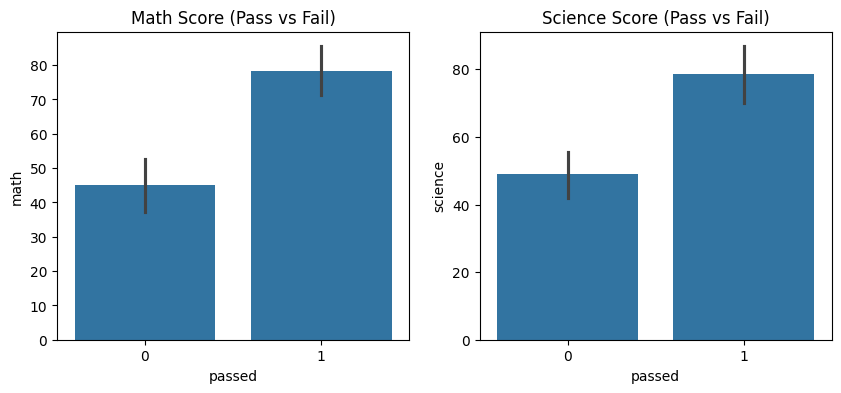

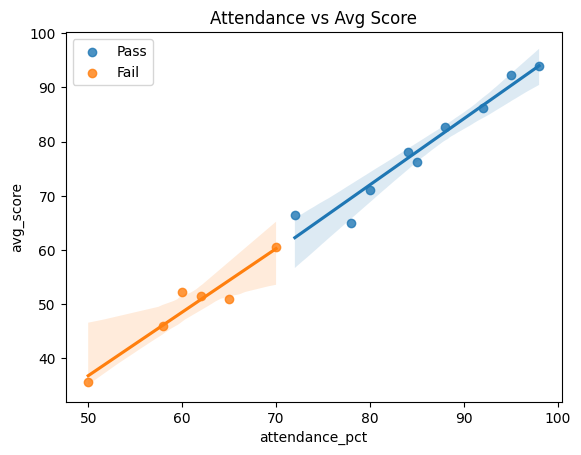

In [12]:
#Task 3
import seaborn as sns
import matplotlib.pyplot as plt
#Bar plot
plt.figure(figsize=(10,4))

#Math
plt.subplot(1,2,1)
sns.barplot(data=df,x='passed',y='math')
plt.title("Math Score (Pass vs Fail)")

#Science
plt.subplot(1,2,2)
sns.barplot(data=df,x='passed',y='science')
plt.title("Science Score (Pass vs Fail)")

plt.savefig("seaborn_bar.png")
plt.show()

#Scatter & Regression
plt.figure()
#Pass students
sns.regplot(data=df[df['passed']==1],
            x='attendance_pct',
            y='avg_score',
            label='Pass')
#Fail students
sns.regplot(data=df[df['passed']==0],
            x='attendance_pct',
            y='avg_score',
            label='Fail')
plt.legend()
plt.title("Attendance vs Avg Score")
plt.savefig("seaborn_scatter.png")
plt.show()

# Seaborn vs matplotlib
# Seaborn is easier than Matplotlib as it automatically creates better looking graphs.
# It requires less code for complex plot like regeression.
# Matplotlib gives more control, but Seaborn is faster and simpler.


Training Accuracy: 1.0
Test Accuracy: 1.0

Results:

Jack - Actual: 0 Predicted: 0 - Correct
Liam - Actual: 0 Predicted: 0 - Correct
Alice - Actual: 1 Predicted: 1 - Correct

Feature Importance:

english : 0.8125127982724648
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155
pe : 0.47497406284967797
math : 0.43794393086873595
science : 0.3230097624690249
history : 0.26292892629062437


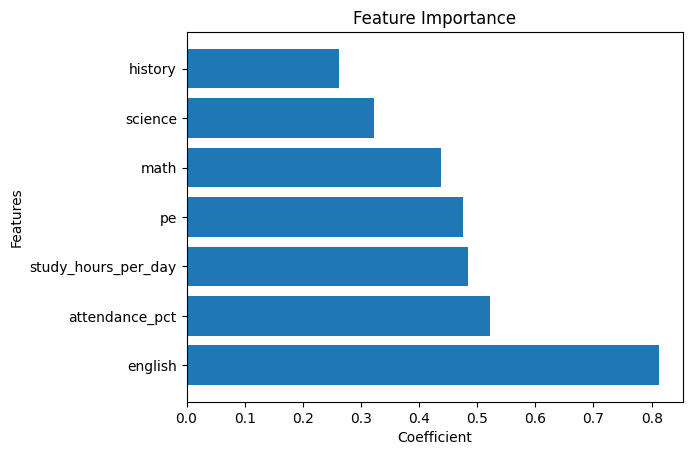


New Student: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
#Task 4
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

features= ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X=df[features]
y=df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Split

scaler = StandardScaler()  #Scale
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model=LogisticRegression()
model.fit(X_train_scaled,y_train)
print("Training Accuracy:",model.score(X_train_scaled,y_train))

y_pred = model.predict(X_test_scaled)
print("Test Accuracy:", model.score(X_test_scaled, y_test))

names = df.loc[X_test.index, 'name'] #Show results with names
print("\nResults:\n")
for i in range(len(names)):
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    if actual == predicted:
        result = "Correct"
    else:
        result = "Wrong"
    print(names.iloc[i], "- Actual:", actual, "Predicted:", predicted, "-", result)

coeff = model.coef_[0]
data = list(zip(features, coeff)) #Pair with feature names
data.sort(key=lambda x: abs(x[1]), reverse=True) #Sort by importance

print("\nFeature Importance:\n")
for f, c in data:
    print(f, ":", c)

# Plot
names = [x[0] for x in data]
values = [x[1] for x in data]
colors = []

for v in values:
    if v > 0:
        colors.append("green")
    else:
        colors.append("red")

plt.barh(names, values)
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.show()

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled = scaler.transform(new_student)
prediction = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

if prediction[0] == 1:
    print("\nNew Student: Pass")
else:
    print("\nNew Student: Fail")

print("Probability:", prob)






